# Wheeler-Kiladis wavenumber-frequency spectrum vs. forecast lead time
Companion to `kf_pan.ipynb` (free-running).  Instead of a continuous CESM run, this notebook pools **CESM2 S2S PRECT hindcasts** across ensemble members and start dates and computes the WK spectrum at each requested **lead day**.

Data: `/glade/campaign/cesm/development/cross-wg/S2S/CESM2/S2SHINDCASTS/daily/`

**Workflow**
1. (Once) build PRECT cache — one file per `(member, year)` with dims `(start_date, lead_day, lat, lon)` and PRECT in mm/day.
2. For each lead day L in `LEAD_DAYS`, collect a segment of length `N_DAY_WIN` starting at day L from every `(start_date × member)` hindcast.
3. Feed the pooled segments into `kf_pan_utils.compute_wk_spectrum_from_segments` — each segment is treated as one independent WK window.
4. Plot side-by-side WK panels, one per lead day.

## Imports

In [57]:
%load_ext autoreload
%autoreload 2

import os, sys
os.environ.setdefault('DASK_TEMPORARY_DIRECTORY', '/glade/derecho/scratch/rneale/dask-temp')

import importlib
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.dirname(os.path.abspath('kf_pan_utils.py')))
import kf_pan_utils           as kfp
import kf_pan_hindcast_utils  as kfh
importlib.reload(kfp)
importlib.reload(kfh)

from dask.distributed import Client
from dask_jobqueue import PBSCluster

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## (Optional) Dask cluster
Only useful for the cache build if you want to parallelize; the WK spectrum itself is single-process.

In [58]:
cluster = PBSCluster(
    account='P03010039',
    interface='ext',
    walltime='04:00:00',
    queue='main',
    cores=4,
    memory='32GB',
    processes=4,
    local_directory='/glade/derecho/scratch/rneale/dask-temp',
    log_directory='/glade/derecho/scratch/rneale/dask-temp',
)
cluster.scale(jobs=4)
client = Client(cluster)
client

/glade/work/rneale/conda-envs/neale_vproc2/lib/python3.14/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 38363 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: dask_jobqueue.PBSCluster
Dashboard: /node/crhtc68.hpc.ucar.edu/44860/proxy/38363/status,
Dashboard: /node/crhtc68.hpc.ucar.edu/44860/proxy/38363/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://128.117.208.176:42085,Workers: 0
Dashboard: /node/crhtc68.hpc.ucar.edu/44860/proxy/38363/status,Total threads: 0
Started: Just now,Total memory: 0 B


## Top-level options

In [ ]:
# ── Data & cache directories ───────────────────────────────────────────────
DATA_DIR        = kfh.DATA_DIR
CACHE_DIR       = kfh.CACHE_DIR
IMERG_DAILY_DIR = kfh.IMERG_DAILY_DIR

# ── Cache build selection ─────────────────────────────────────────────────
# None = all available; e.g. YEARS=list(range(1999, 2020)), MONTHS=[12, 1, 2]
YEARS  = [2010, 2011, 2012, 2013, 2014, 2015]
MONTHS = None

# Cache options (all 46 lead days are always written; lat clipped to ±25°)
LAT_BOUND_CACHE  = 25.0
OVERWRITE_CACHE  = False
N_WORKERS_CACHE  = 8

# ── Analysis selection ────────────────────────────────────────────────────
# Restrict which cached years/members contribute.  None → all cached.
ANALYSIS_YEARS   = None
ANALYSIS_MEMBERS = None

# Season filter on start dates: 'DJF' | 'MAM' | 'JJA' | 'SON' | None (all)
SEASON = None

# ── Lead-bucket WK parameters ────────────────────────────────────────────
# Each bucket B uses lead days [(B-1)*D+1 .. B*D] from every start date.
# With D = 7-day cadence, bucket 1 = week 1 (days 1-7), 2 = week 2, ...
# Chained across start dates → continuous daily series → standard WK windowing.
LEAD_BUCKETS    = [1, 3, 5]        # week 1, week 3, week 5
DAYS_PER_BUCKET = 7                # match the start-date cadence
N_DAY_WIN       = 96               # WK window (long enough for MJO)
N_DAY_SKIP      = -65              # WK default (overlap between windows)

# ── Std-map lead days (single-lead-day pool; forecasts 7 days apart is fine) ─
STD_LEAD_DAYS = [1, 5, 10, 20, 30, 45]

# ── Observational reference (IMERG daily 1°) ──────────────────────────────
OBS_CLIM_YRS = (2011, 2015)

# ── WK plot options (mirrored from kf_pan.ipynb) ─────────────────────────
VAR0      = 'PRECT'
LAT_BOUND = 15.0
MIN_WAV   = -15
MAX_WAV   =  15
MAX_FREQ  =  0.5
ANOM_PLOT = False
SAVE_DIR   = './figs_kf_pan_hindcast'
FIG_PREFIX = 'kf_pan_hindcast'

assert max(LEAD_BUCKETS) * DAYS_PER_BUCKET <= 46, \
    (f'bucket {max(LEAD_BUCKETS)} × {DAYS_PER_BUCKET} d/bucket = '
     f'{max(LEAD_BUCKETS)*DAYS_PER_BUCKET} d exceeds the 46-day hindcast length')

print(f'lead buckets   : {LEAD_BUCKETS}  ({DAYS_PER_BUCKET} d each)')
print(f'std lead days  : {STD_LEAD_DAYS}')
print(f'n_day_win/skip : {N_DAY_WIN}/{N_DAY_SKIP}')
print(f'season         : {SEASON or "all months"}')
print(f'years          : cache={YEARS or "all"}   analysis={ANALYSIS_YEARS or "all"}')
print(f'IMERG clim     : {OBS_CLIM_YRS[0]}-{OBS_CLIM_YRS[1]}')
print(f'cache dir      : {CACHE_DIR}')

### Contour levels
Same defaults as `kf_pan.ipynb` — override here for finer/wider ranges.

In [60]:
fig_1_levels  = np.linspace(-1.0, 0.4, 15)
fig_2_levels  = fig_1_levels.copy()
# ratio to background: 6 intervals below 1, 6 above — 1.0 at the visual midpoint
fig_3a_levels = np.array([0.4, 0.5, 0.6, 0.7, 0.8, 0.9,
                           1.0, 1.1, 1.25, 1.5, 1.75, 2.5, 3.0])
fig_3b_levels = fig_3a_levels.copy()

anom_levels   = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9,
                           1.1, 1.2, 1.4, 1.6, 1.8, 2.0, 2.4, 3.0])

## 1. File inventory

In [61]:
file_df = kfh.list_hindcast_files(DATA_DIR, years=YEARS, months=MONTHS)
print(file_df.head(10))

list_hindcast_files: 3453 files  | 6 years  | 313 start dates  | 21 members
   year  month start_date  member  \
0  2010      1 2010-01-04       0   
1  2010      1 2010-01-04       1   
2  2010      1 2010-01-04       2   
3  2010      1 2010-01-04       3   
4  2010      1 2010-01-04       4   
5  2010      1 2010-01-04       5   
6  2010      1 2010-01-04       6   
7  2010      1 2010-01-04       7   
8  2010      1 2010-01-04       8   
9  2010      1 2010-01-04       9   

                                                path  
0  /glade/campaign/cesm/development/cross-wg/S2S/...  
1  /glade/campaign/cesm/development/cross-wg/S2S/...  
2  /glade/campaign/cesm/development/cross-wg/S2S/...  
3  /glade/campaign/cesm/development/cross-wg/S2S/...  
4  /glade/campaign/cesm/development/cross-wg/S2S/...  
5  /glade/campaign/cesm/development/cross-wg/S2S/...  
6  /glade/campaign/cesm/development/cross-wg/S2S/...  
7  /glade/campaign/cesm/development/cross-wg/S2S/...  
8  /glade/campaign/ce

## 2. Build PRECT cache (skip if already done)
One NetCDF per `(member, year)` with PRECT in mm/day, dims `(start_date, lead_day, lat, lon)`.  Adding a new year never touches existing files.

In [62]:
kfh.prect_cache_status(cache_dir=CACHE_DIR)

PRECT cache: 11 file(s) in /glade/work/rneale/python-netcdf/hindcast_kf_pan
  members: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]   years: [2000]
  m00: [2000] OK
  m01: [2000] OK
  m02: [2000] OK
  m03: [2000] OK
  m04: [2000] OK
  m05: [2000] OK
  m06: [2000] OK
  m07: [2000] OK
  m08: [2000] OK
  m09: [2000] OK
  m10: [2000] OK


In [63]:
kfh.build_prect_cache(
    data_dir        = DATA_DIR,
    cache_dir       = CACHE_DIR,
    years           = YEARS,
    months          = MONTHS,
    lat_bound_cache = LAT_BOUND_CACHE,
    overwrite       = OVERWRITE_CACHE,
    n_workers       = N_WORKERS_CACHE,
)

list_hindcast_files: 3453 files  | 6 years  | 313 start dates  | 21 members

build_prect_cache: 6 year(s)  →  76 output files  (n_workers=8, lat_bound_cache=±25.0°, nlat=54, nlon=288)
  2010: 11 members  (m00–m10)
  2011: 11 members  (m00–m10)
  2012: 21 members  (m00–m20)
  2013: 11 members  (m00–m10)
  2014: 11 members  (m00–m10)
  2015: 11 members  (m00–m10)

  year 2010: 11 members  52 start dates  (2010-01-04 → 2010-12-27)
    m00: 20/52 start dates  (54s)
    m03: 20/52 start dates  (55s)
    m02: 20/52 start dates  (55s)
    m04: 20/52 start dates  (55s)
    m05: 20/52 start dates  (56s)
    m07: 20/52 start dates  (56s)
    m01: 20/52 start dates  (56s)
    m06: 20/52 start dates  (57s)
    m03: 40/52 start dates  (112s)
    m02: 40/52 start dates  (113s)
    m04: 40/52 start dates  (113s)
    m00: 40/52 start dates  (113s)
    m07: 40/52 start dates  (114s)
    m05: 40/52 start dates  (114s)
    m01: 40/52 start dates  (114s)
    m06: 40/52 start dates  (115s)
    m03: 52/52 s

HDF5-DIAG: Error detected in HDF5 (1.14.6) thread 3:
  #000: H5F.c line 496 in H5Fis_accessible(): unable to determine if file is accessible as HDF5
    major: File accessibility
    minor: Not an HDF5 file
  #001: H5VLcallback.c line 3913 in H5VL_file_specific(): file specific failed
    major: Virtual Object Layer
    minor: Can't operate on object
  #002: H5VLcallback.c line 3848 in H5VL__file_specific(): file specific failed
    major: Virtual Object Layer
    minor: Can't operate on object
  #003: H5VLnative_file.c line 344 in H5VL__native_file_specific(): error in HDF5 file check
    major: File accessibility
    minor: Can't get value
  #004: H5Fint.c line 1055 in H5F__is_hdf5(): unable to open file
    major: File accessibility
    minor: Unable to initialize object
  #005: H5FD.c line 787 in H5FD_open(): can't open file
    major: Virtual File Layer
    minor: Unable to open file
  #006: H5FDsec2.c line 323 in H5FD__sec2_open(): unable to open file: name = '/glade/work/rneale/

    m03: saved → prect_hindcast_m03_2010.nc  (146.9s)
    m02: 52/52 start dates  (147s)
    m02: saved → prect_hindcast_m02_2010.nc  (147.3s)


HDF5-DIAG: Error detected in HDF5 (1.14.6) thread 1:
  #000: H5F.c line 496 in H5Fis_accessible(): unable to determine if file is accessible as HDF5
    major: File accessibility
    minor: Not an HDF5 file
  #001: H5VLcallback.c line 3913 in H5VL_file_specific(): file specific failed
    major: Virtual Object Layer
    minor: Can't operate on object
  #002: H5VLcallback.c line 3848 in H5VL__file_specific(): file specific failed
    major: Virtual Object Layer
    minor: Can't operate on object
  #003: H5VLnative_file.c line 344 in H5VL__native_file_specific(): error in HDF5 file check
    major: File accessibility
    minor: Can't get value
  #004: H5Fint.c line 1055 in H5F__is_hdf5(): unable to open file
    major: File accessibility
    minor: Unable to initialize object
  #005: H5FD.c line 787 in H5FD_open(): can't open file
    major: Virtual File Layer
    minor: Unable to open file
  #006: H5FDsec2.c line 323 in H5FD__sec2_open(): unable to open file: name = '/glade/work/rneale/

    m00: 52/52 start dates  (148s)


...

HDF5-DIAG: Error detected in HDF5 (1.14.6) thread 3:
  #000: H5F.c line 496 in H5Fis_accessible(): unable to determine if file is accessible as HDF5
    major: File accessibility
    minor: Not an HDF5 file
  #001: H5VLcallback.c line 3913 in H5VL_file_specific(): file specific failed
    major: Virtual Object Layer
    minor: Can't operate on object
  #002: H5VLcallback.c line 3848 in H5VL__file_specific(): file specific failed
    major: Virtual Object Layer
    minor: Can't operate on object
  #003: H5VLnative_file.c line 344 in H5VL__native_file_specific(): error in HDF5 file check
    major: File accessibility
    minor: Can't get value
  #004: H5Fint.c line 1055 in H5F__is_hdf5(): unable to open file
    major: File accessibility
    minor: Unable to initialize object
  #005: H5FD.c line 787 in H5FD_open(): can't open file
    major: Virtual File Layer
    minor: Unable to open file
  #006: H5FDsec2.c line 323 in H5FD__sec2_open(): unable to open file: name = '/glade/work/rneale/

    m10: saved → prect_hindcast_m10_2015.nc  (53.1s)
    m09: 52/52 start dates  (53s)
    m09: saved → prect_hindcast_m09_2015.nc  (53.5s)


HDF5-DIAG: Error detected in HDF5 (1.14.6) thread 2:
  #000: H5F.c line 496 in H5Fis_accessible(): unable to determine if file is accessible as HDF5
    major: File accessibility
    minor: Not an HDF5 file
  #001: H5VLcallback.c line 3913 in H5VL_file_specific(): file specific failed
    major: Virtual Object Layer
    minor: Can't operate on object
  #002: H5VLcallback.c line 3848 in H5VL__file_specific(): file specific failed
    major: Virtual Object Layer
    minor: Can't operate on object
  #003: H5VLnative_file.c line 344 in H5VL__native_file_specific(): error in HDF5 file check
    major: File accessibility
    minor: Can't get value
  #004: H5Fint.c line 1055 in H5F__is_hdf5(): unable to open file
    major: File accessibility
    minor: Unable to initialize object
  #005: H5FD.c line 787 in H5FD_open(): can't open file
    major: Virtual File Layer
    minor: Unable to open file
  #006: H5FDsec2.c line 323 in H5FD__sec2_open(): unable to open file: name = '/glade/work/rneale/

    m08: 52/52 start dates  (55s)
    m08: saved → prect_hindcast_m08_2015.nc  (54.8s)

build_prect_cache: done.


HDF5-DIAG: Error detected in HDF5 (1.14.6) thread 1:
  #000: H5F.c line 496 in H5Fis_accessible(): unable to determine if file is accessible as HDF5
    major: File accessibility
    minor: Not an HDF5 file
  #001: H5VLcallback.c line 3913 in H5VL_file_specific(): file specific failed
    major: Virtual Object Layer
    minor: Can't operate on object
  #002: H5VLcallback.c line 3848 in H5VL__file_specific(): file specific failed
    major: Virtual Object Layer
    minor: Can't operate on object
  #003: H5VLnative_file.c line 344 in H5VL__native_file_specific(): error in HDF5 file check
    major: File accessibility
    minor: Can't get value
  #004: H5Fint.c line 1055 in H5F__is_hdf5(): unable to open file
    major: File accessibility
    minor: Unable to initialize object
  #005: H5FD.c line 787 in H5FD_open(): can't open file
    major: Virtual File Layer
    minor: Unable to open file
  #006: H5FDsec2.c line 323 in H5FD__sec2_open(): unable to open file: name = '/glade/work/rneale/

## 3. Compute WK spectra — OBS + lead-bucket cases
Each panel uses the same standard-WK windowing (`N_DAY_WIN` days, `N_DAY_SKIP` skip).

- **OBS clim** — IMERG over `OBS_CLIM_YRS`, standard multi-window WK.
- **OBS matched (week 1)** — for each start date, IMERG days 1-`DAYS_PER_BUCKET` — the calendar window the week-1 forecast verifies against — chained across start dates, cut into WK windows.
- **Week B** — for each `(member, year)`, chain lead days `(B-1)*D+1 .. B*D` from every start date into a continuous daily series (matches the 7-day cadence), cut into WK windows, pool across `(member, year)`.

Panels are laid out automatically by `plot_wk_panel` (2 columns × ceil(N/2) rows).

In [ ]:
# ── 3a. IMERG climatology (continuous record → pooled segments) ────────────
res_obs_clim = kfh.imerg_wk_spectrum_climatology(
    yr0        = OBS_CLIM_YRS[0],
    yr1        = OBS_CLIM_YRS[1],
    n_day_win  = N_DAY_WIN,
    lat_bound  = LAT_BOUND,
    n_day_skip = 0,                      # non-overlapping for the long clim record
    imerg_dir  = IMERG_DAILY_DIR,
    label      = f'IMERG clim {OBS_CLIM_YRS[0]}-{OBS_CLIM_YRS[1]}',
)

# ── 3b. IMERG matched to hindcast start dates, aligned to week-1 verification ─
start_dates = kfh.hindcast_start_dates(
    cache_dir = CACHE_DIR,
    years     = ANALYSIS_YEARS,
    members   = ANALYSIS_MEMBERS,
    season    = SEASON,
)
print(f'hindcast start dates: n={len(start_dates)}  '
      f'{start_dates.min().date()} → {start_dates.max().date()}')

res_obs_matched = kfh.imerg_wk_spectrum_matched_bucket(
    start_dates     = start_dates,
    bucket_idx      = 1,                 # week-1 verification window
    days_per_bucket = DAYS_PER_BUCKET,
    n_day_win       = N_DAY_WIN,
    n_day_skip      = N_DAY_SKIP,
    lat_bound       = LAT_BOUND,
    imerg_dir       = IMERG_DAILY_DIR,
    label           = 'IMERG matched (week 1)',
)

# ── 3c. CESM hindcast lead-bucket spectra ─────────────────────────────────
res_buckets = kfh.wk_spectra_lead_buckets(
    bucket_idxs     = LEAD_BUCKETS,
    days_per_bucket = DAYS_PER_BUCKET,
    n_day_win       = N_DAY_WIN,
    n_day_skip      = N_DAY_SKIP,
    cache_dir       = CACHE_DIR,
    years           = ANALYSIS_YEARS,
    members         = ANALYSIS_MEMBERS,
    season          = SEASON,
    lat_bound       = LAT_BOUND,
)

results     = [res_obs_clim, res_obs_matched, *res_buckets]
case_labels = [r['label'] for r in results]
print('\nPanels:')
for r in results:
    print(f"  {r['label']:35s}  n_segments={r['n_segments']}  n_day_win={r['n_day_win']}")

## 4. Dispersion curves

In [68]:
Apzwn, Afreq = kfp.gen_dispersion_curves(
    ahe=(50., 25., 12.),
    n_wave_type=6,
    n_planetary_wave=50,
)
print('Dispersion curves:', Apzwn.shape)

Dispersion curves: (6, 3, 50)


## 5. Plot WK panels
One figure per plot type (Asym / Sym / BG / Asym÷BG / Sym÷BG), one panel per lead day.

Saved: figs_kf_pan_hindcast/kf_pan_hindcast_PRECT_PRECT_asym.png
Saved: figs_kf_pan_hindcast/kf_pan_hindcast_PRECT_PRECT_sym.png
Saved: figs_kf_pan_hindcast/kf_pan_hindcast_PRECT_PRECT_bg.png
Saved: figs_kf_pan_hindcast/kf_pan_hindcast_PRECT_PRECT_asym_r.png
Saved: figs_kf_pan_hindcast/kf_pan_hindcast_PRECT_PRECT_sym_r.png


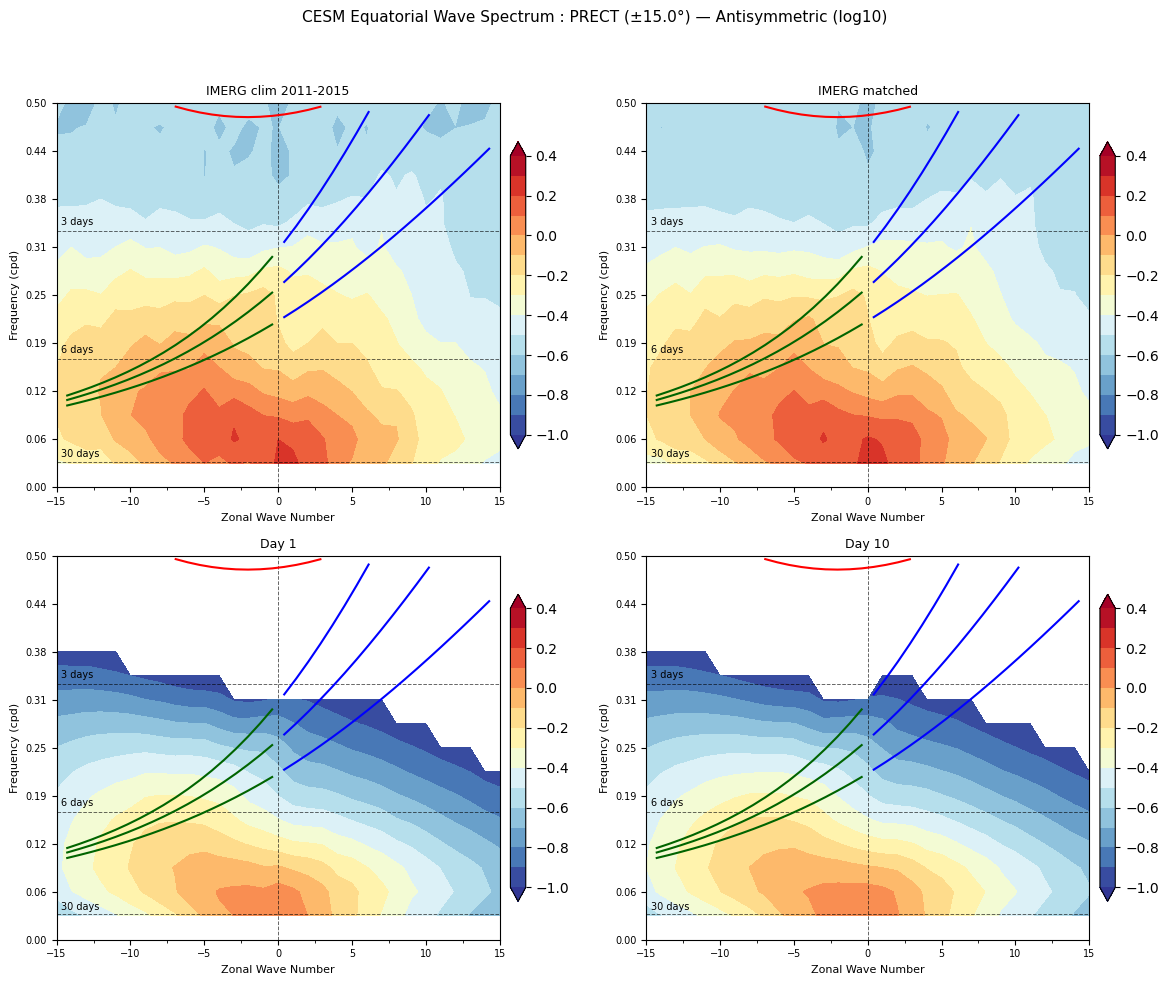

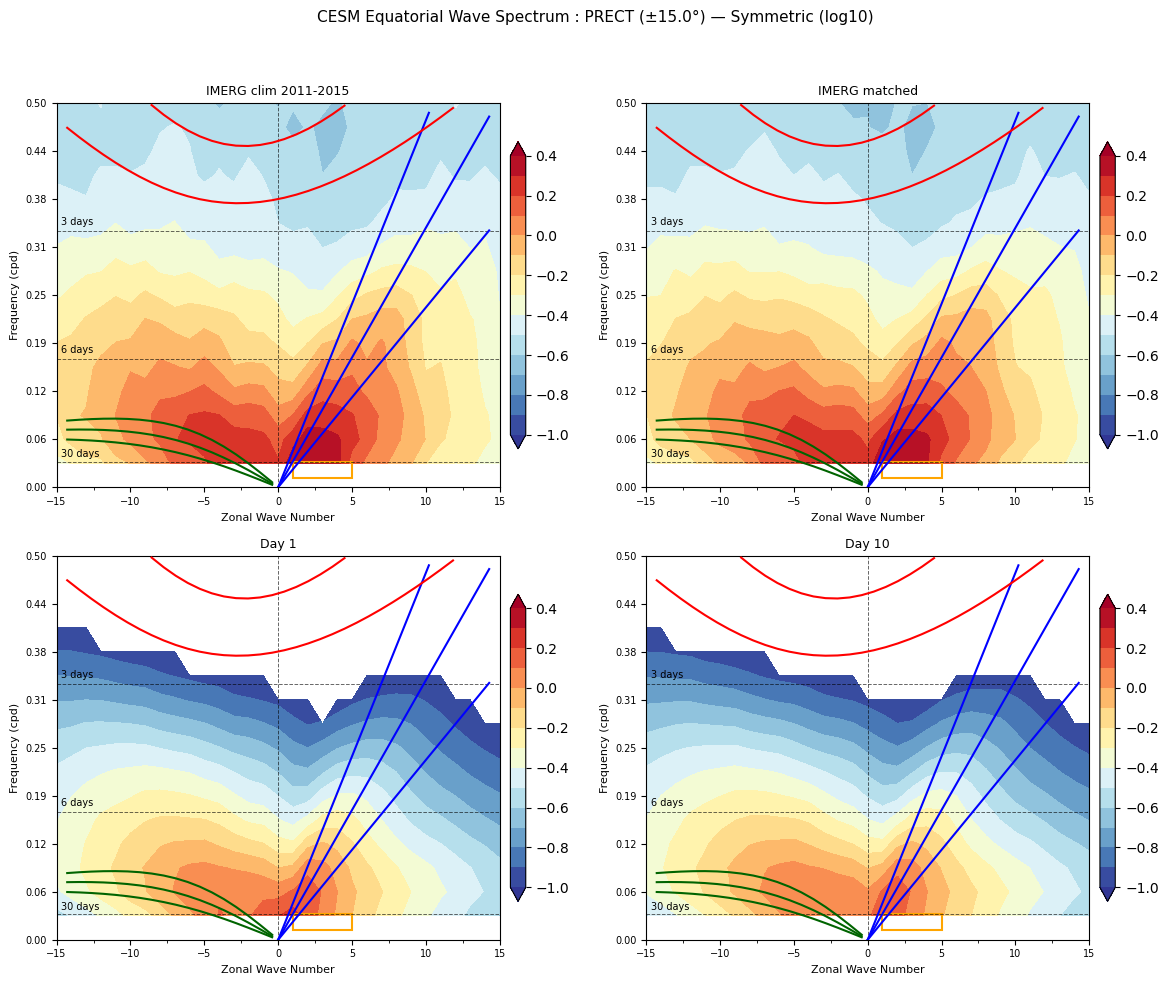

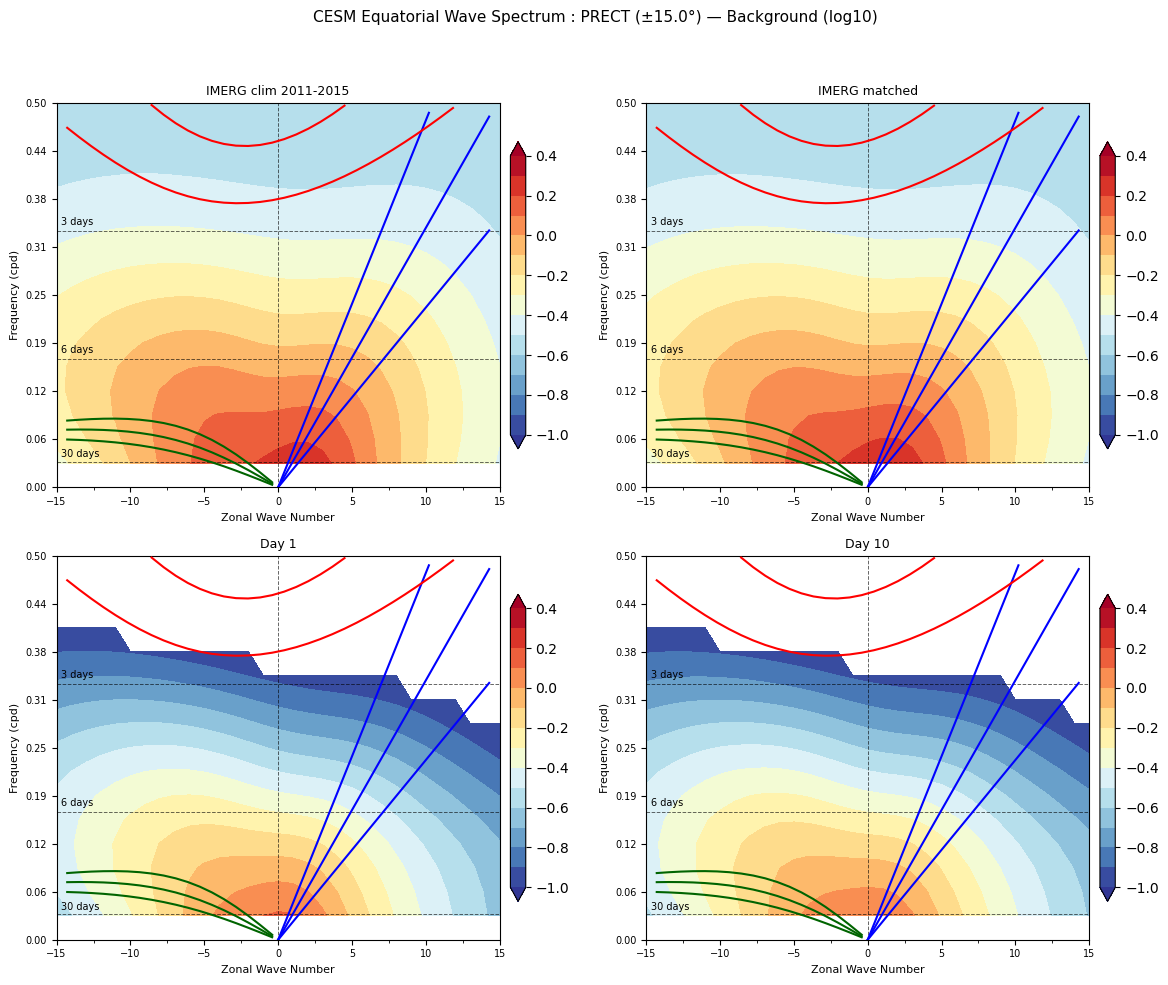

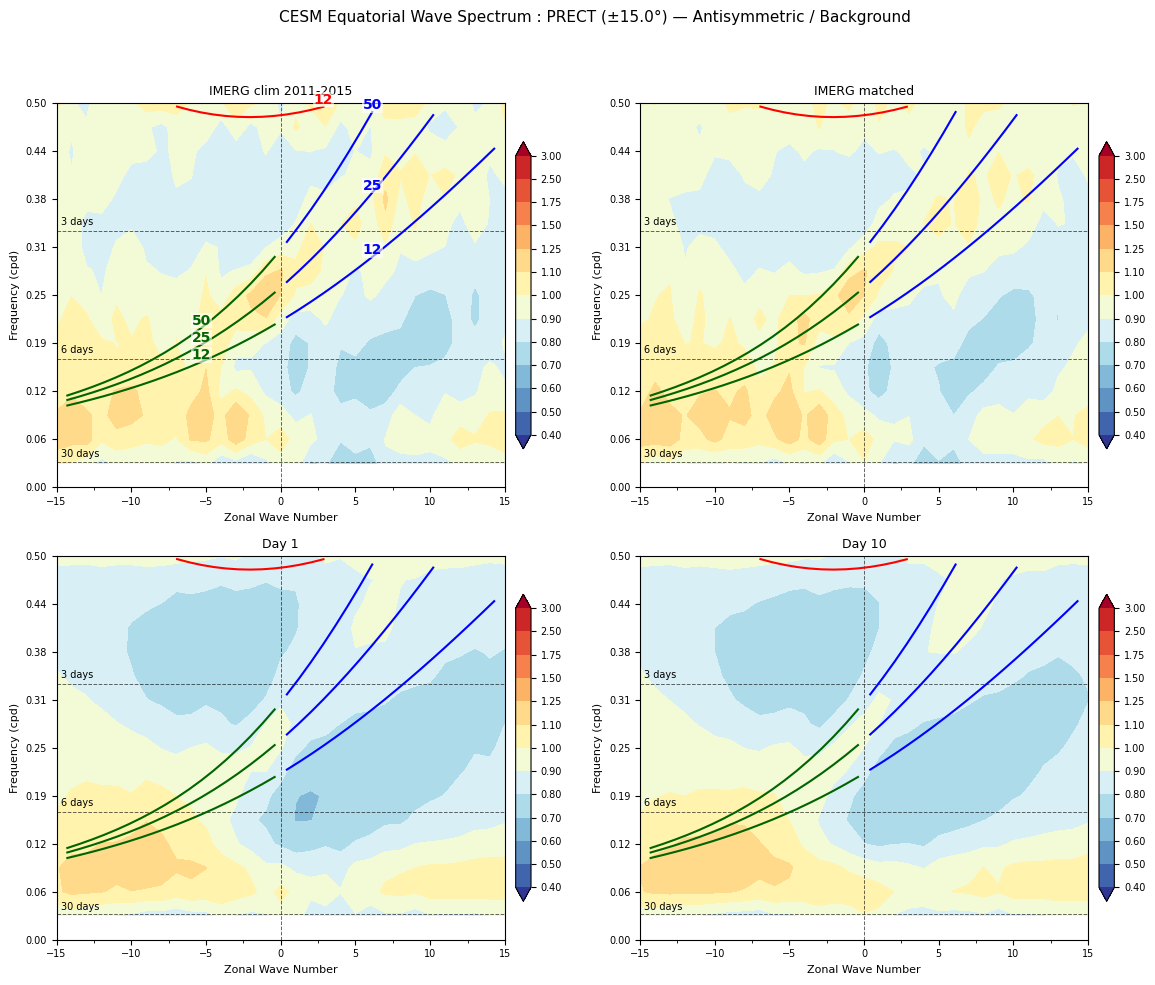

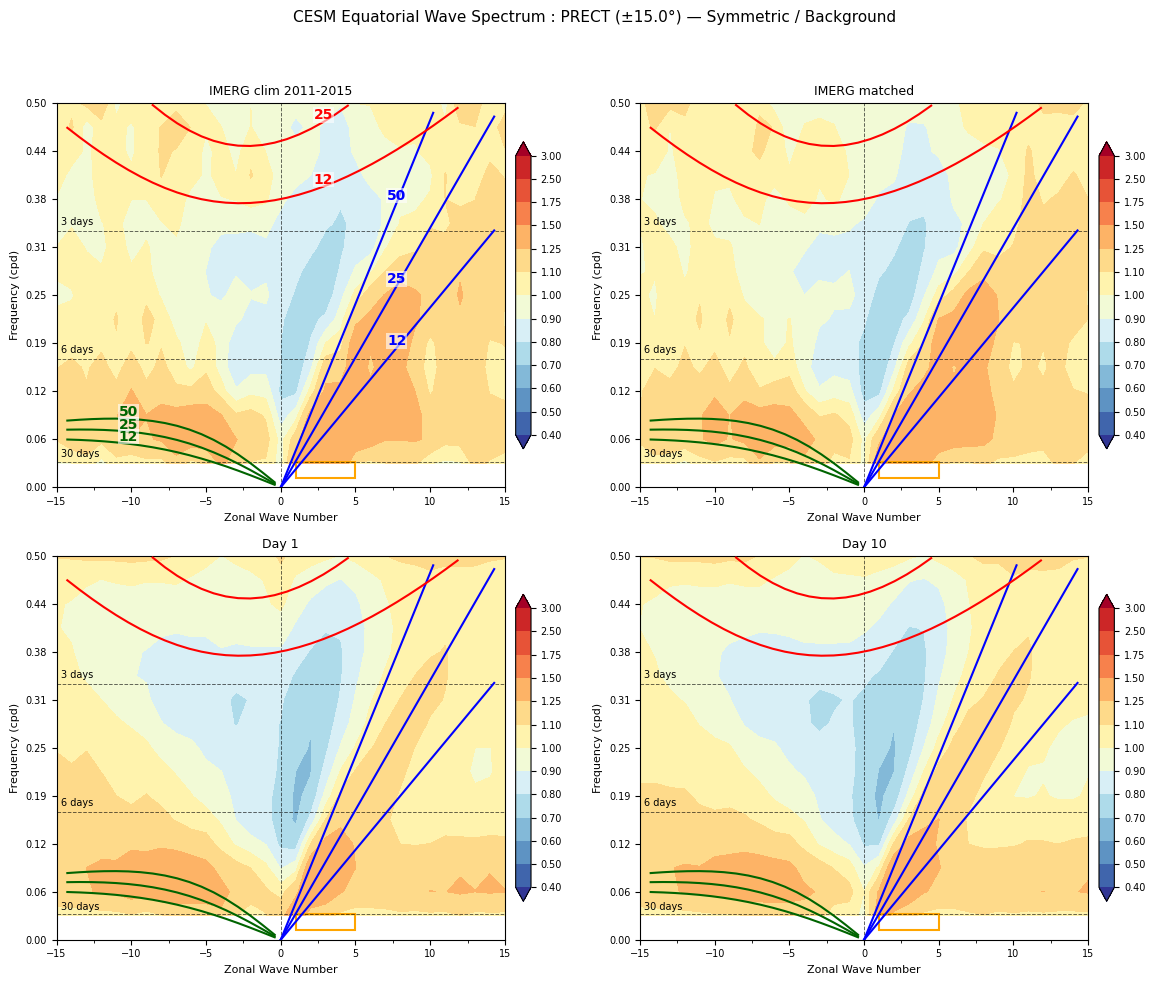

DONE


In [69]:
figs = kfp.plot_wk_panel(
    results       = results,
    case_labels   = case_labels,
    var_name      = VAR0,
    lat_bound     = LAT_BOUND,
    fig_1_levels  = fig_1_levels,
    fig_2_levels  = fig_2_levels,
    fig_3a_levels = fig_3a_levels,
    fig_3b_levels = fig_3b_levels,
    anom_plot     = ANOM_PLOT,
    anom_levels   = anom_levels,
    Apzwn         = Apzwn,
    Afreq         = Afreq,
    add_disp_lines= True,
    add_mjo_box   = True,
    min_wav       = MIN_WAV,
    max_wav       = MAX_WAV,
    max_freq      = MAX_FREQ,
    cmap          = 'RdYlBu_r',
    cmap_ratio    = 'RdYlBu_r',
    log_cutoff    = -1.0,
    save_dir      = SAVE_DIR,
    fig_prefix    = f'{FIG_PREFIX}_{VAR0}',
)
plt.show()
print('DONE')

## 6. Std-dev maps — same data selection as the WK panels
For each case, pool every sample and take the per-grid-point temporal standard deviation.  Since it's just a scalar per (lat, lon), the weekly cadence of hindcast start dates isn't a problem — one lead-day value per start date × member × year is enough to build a robust std.

- **OBS clim** — all IMERG days in `OBS_CLIM_YRS`.
- **OBS matched** — IMERG restricted to the hindcast start dates.
- **Day L** — for each L in `STD_LEAD_DAYS`, pool the lead-L value from every `(start_date × member × year)`.

In [ ]:
# ── Std maps: obs (clim + matched) + one per STD_LEAD_DAY ──────────────────
std_obs_clim = kfh.imerg_std_map_climatology(
    yr0       = OBS_CLIM_YRS[0],
    yr1       = OBS_CLIM_YRS[1],
    lat_bound = LAT_BOUND,
    imerg_dir = IMERG_DAILY_DIR,
    label     = f'IMERG clim {OBS_CLIM_YRS[0]}-{OBS_CLIM_YRS[1]}',
)

std_obs_matched = kfh.imerg_std_map_matched(
    start_dates = start_dates,
    lat_bound   = LAT_BOUND,
    imerg_dir   = IMERG_DAILY_DIR,
    label       = 'IMERG matched',
)

std_lead = kfh.hindcast_std_maps_lead_days(
    lead_days = STD_LEAD_DAYS,
    cache_dir = CACHE_DIR,
    years     = ANALYSIS_YEARS,
    members   = ANALYSIS_MEMBERS,
    season    = SEASON,
    lat_bound = LAT_BOUND,
)

std_results = [std_obs_clim, std_obs_matched, *std_lead]
print('\nStd panels:')
for r in std_results:
    print(f"  {r['label']:35s}  n_samples={r['n_samples']}")

In [ ]:
# ── Plot the std panel grid ────────────────────────────────────────────────
from pathlib import Path
std_save = Path(SAVE_DIR) / f'{FIG_PREFIX}_{VAR0}_std.png'

fig_std = kfh.plot_std_panel(
    std_results,
    var_name  = VAR0,
    units     = 'mm/day',
    nx        = 3,             # 3 columns per row
    cmap      = 'YlGnBu',
    save_path = std_save,
    fig_title = f'{VAR0} temporal std (±{LAT_BOUND:.0f}°) — OBS vs. lead day',
)
plt.show()

## Quick-look at one lead day

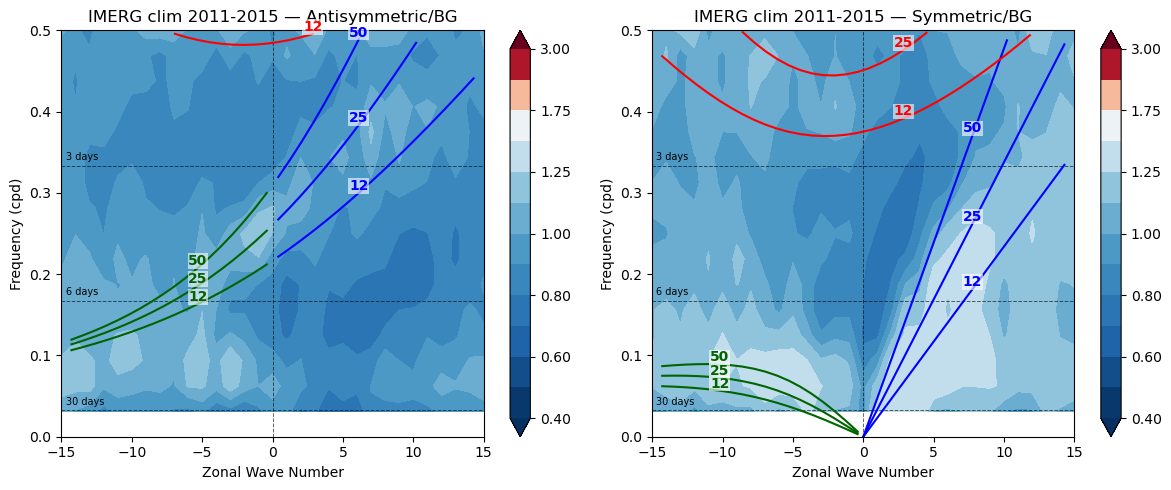

In [70]:
ic_show = 0        # index into results
res     = results[ic_show]
wave, freq = res['wave'], res['freq']

iw0 = np.searchsorted(wave, MIN_WAV)
iw1 = np.searchsorted(wave, MAX_WAV) + 1
if0 = np.searchsorted(freq, 0.0)
if1 = np.searchsorted(freq, MAX_FREQ) + 1

W, F   = wave[iw0:iw1], freq[if0:if1]
WW, FF = np.meshgrid(W, F)

sym_r  = (res['psumsym_nl']  / res['psumb_nl'])[iw0:iw1, if0:if1].T
asym_r = (res['psumanti_nl'] / res['psumb_nl'])[iw0:iw1, if0:if1].T

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, data, ttl in zip(axes,
                          [asym_r, sym_r],
                          ['Antisymmetric/BG', 'Symmetric/BG']):
    cf = ax.contourf(WW, FF, data, levels=fig_3a_levels, cmap='RdBu_r', extend='both')
    plt.colorbar(cf, ax=ax)
    kfp.add_hor_vert_lines(ax, MIN_WAV, MAX_WAV)
    kfp.add_dispersion_curves(
        ax, Apzwn, Afreq,
        plot_type='sym' if 'Sym' in ttl else 'asym',
        min_wav=MIN_WAV, max_wav=MAX_WAV, max_freq=MAX_FREQ,
    )
    ax.set_xlim(MIN_WAV, MAX_WAV)
    ax.set_ylim(0, MAX_FREQ)
    ax.set_title(f"{case_labels[ic_show]} — {ttl}")
    ax.set_xlabel('Zonal Wave Number')
    ax.set_ylabel('Frequency (cpd)')

fig.tight_layout()
plt.show()